In [28]:
"""
Project: Strategic Credit Risk & Profitability Analysis
Author: [Zixuan Zhao]
Description: Data engineering and risk modeling for 2.2M loan records.
"""

'\nProject: Strategic Credit Risk & Profitability Analysis\nAuthor: [Zixuan Zhao]\nDescription: Data engineering and risk modeling for 2.2M loan records.\n'

In [10]:
import pandas as pd

# Step 1: Load the dataset
# Setting low_memory=False to handle large datasets efficiently
df = pd.read_csv('loan.csv', low_memory=False)

# Step 2: High-level data integrity check
print("--- Dataset Executive Summary ---")
df.info()

# Step 3: Preview the first 5 records to understand the structure
print("\n--- Data Preview (Top 5 Rows) ---")
df.head()

--- Dataset Executive Summary ---
<class 'pandas.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), str(36)
memory usage: 2.4 GB

--- Data Preview (Top 5 Rows) ---


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# 1. Define the columns essential for Credit Risk Analysis
columns_to_keep = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 
    'sub_grade', 'annual_inc', 'loan_status', 'dti', 'issue_d'
]

# 2. Filter the massive dataset
df_slim = df[columns_to_keep]

# 3. Save to a much smaller CSV file
# This bypasses the technical errors while still giving us a 15x speed boost
df_slim.to_csv('loan_slim.csv', index=False)

print("--- Success! ---")
print("Slim dataset saved as 'loan_slim.csv'.")
print(f"Dataset downsized from 145 columns to {len(columns_to_keep)} columns.")

--- Success! ---
Slim dataset saved as 'loan_slim.csv'.
Dataset downsized from 145 columns to 10 columns.


In [19]:
# Step 1: Load the slim dataset
df_analysis = pd.read_csv('loan_slim.csv')

# Step 2: Clean 'int_rate' column with a check
# Only apply string operations if the column is currently of 'object' (string) type
if df_analysis['int_rate'].dtype == 'object':
    df_analysis['int_rate'] = df_analysis['int_rate'].str.replace('%', '').astype(float) / 100
    print("Column 'int_rate' successfully converted to float.")
else:
    print("Column 'int_rate' is already numeric, skipping conversion.")

# Step 3: High-level Risk Portfolio Analysis
risk_summary = df_analysis.groupby('grade').agg({
    'int_rate': 'mean',
    'loan_amnt': 'mean',
    'annual_inc': 'median'
}).sort_index()

print("\n--- Portfolio Overview by Credit Grade ---")
print(risk_summary)

Column 'int_rate' is already numeric, skipping conversion.

--- Portfolio Overview by Credit Grade ---
        int_rate     loan_amnt  annual_inc
grade                                     
A       7.084558  14603.343210     75000.0
B      10.675819  14173.338199     65000.0
C      14.143793  15038.083318     63000.0
D      18.143304  15711.983007     60000.0
E      21.829848  17453.078392     60000.0
F      25.454203  19124.646531     63000.0
G      28.074255  20383.988741     65000.0


In [20]:
# Step 1: Define the logic for "Bad Loans" (Defaulted/Charged Off)
# In banking, we focus on identifying non-performing assets
bad_indicators = ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off", "In Grace Period", 
                  "Late (16-30 days)", "Late (31-120 days)"]

# Step 2: Create a binary indicator for Bad Loan (1 for Bad, 0 for Good)
df_analysis['is_bad'] = df_analysis['loan_status'].apply(lambda x: 1 if x in bad_indicators else 0)

# Step 3: Calculate Default Rate by Grade
# This is the 'holy grail' metric for Credit Risk analysts
default_analysis = df_analysis.groupby('grade')['is_bad'].mean().reset_index()
default_analysis.columns = ['Grade', 'Default_Rate']
default_analysis['Default_Rate_Pct'] = default_analysis['Default_Rate'].apply(lambda x: f"{x:.2%}")

print("--- Default Rate Analysis by Credit Grade ---")
print(default_analysis)

--- Default Rate Analysis by Credit Grade ---
  Grade  Default_Rate Default_Rate_Pct
0     A      0.037007            3.70%
1     B      0.088550            8.86%
2     C      0.147034           14.70%
3     D      0.207830           20.78%
4     E      0.286651           28.67%
5     F      0.368900           36.89%
6     G      0.406312           40.63%


Matplotlib is building the font cache; this may take a moment.


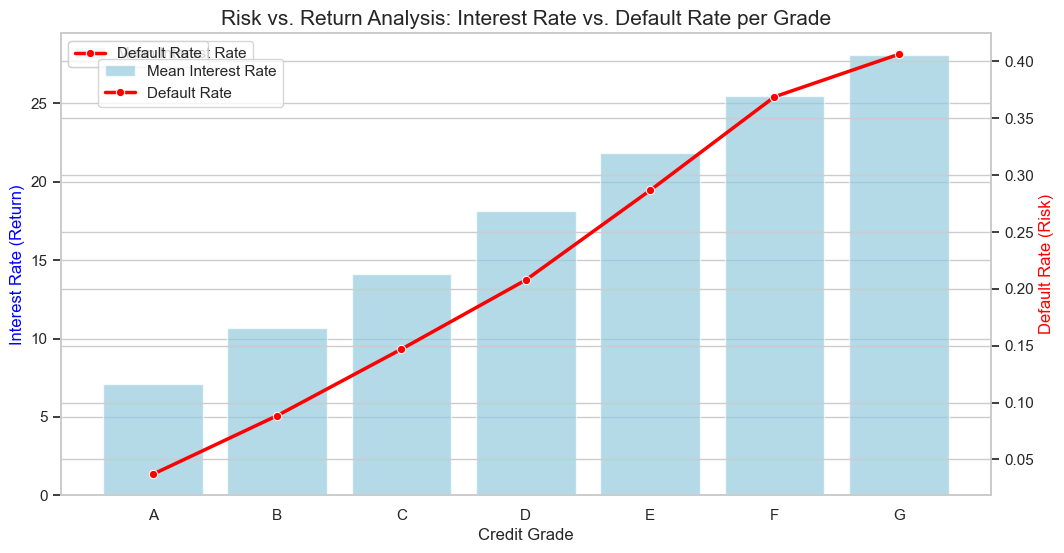

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the visualization data by merging Risk Summary and Default Analysis
# We want to see if the higher interest rate compensates for the higher default rate
viz_data = risk_summary.copy()
viz_data['default_rate'] = default_analysis.set_index('Grade')['Default_Rate']

# Set visual style
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Mean Interest Rate (Returns)
sns.barplot(x=viz_data.index, y=viz_data['int_rate'], ax=ax1, color='skyblue', alpha=0.7, label='Mean Interest Rate')
ax1.set_ylabel('Interest Rate (Return)', color='blue', fontsize=12)
ax1.set_xlabel('Credit Grade', fontsize=12)

# Create a second y-axis for the Default Rate (Risk)
ax2 = ax1.twinx()
sns.lineplot(x=viz_data.index, y=viz_data['default_rate'], ax=ax2, color='red', marker='o', linewidth=2.5, label='Default Rate')
ax2.set_ylabel('Default Rate (Risk)', color='red', fontsize=12)

plt.title('Risk vs. Return Analysis: Interest Rate vs. Default Rate per Grade', fontsize=15)
fig.legend(loc="upper left", bbox_to_anchor=(0.15, 0.85))

plt.show()

--- TRUE Profitability Analysis (Corrected Scale) ---
       int_rate_dec  default_rate  true_net_margin
grade                                             
A          0.070846      0.037007         0.033839
B          0.106758      0.088550         0.018208
C          0.141438      0.147034        -0.005596
D          0.181433      0.207830        -0.026397
E          0.218298      0.286651        -0.068352
F          0.254542      0.368900        -0.114357
G          0.280743      0.406312        -0.125569


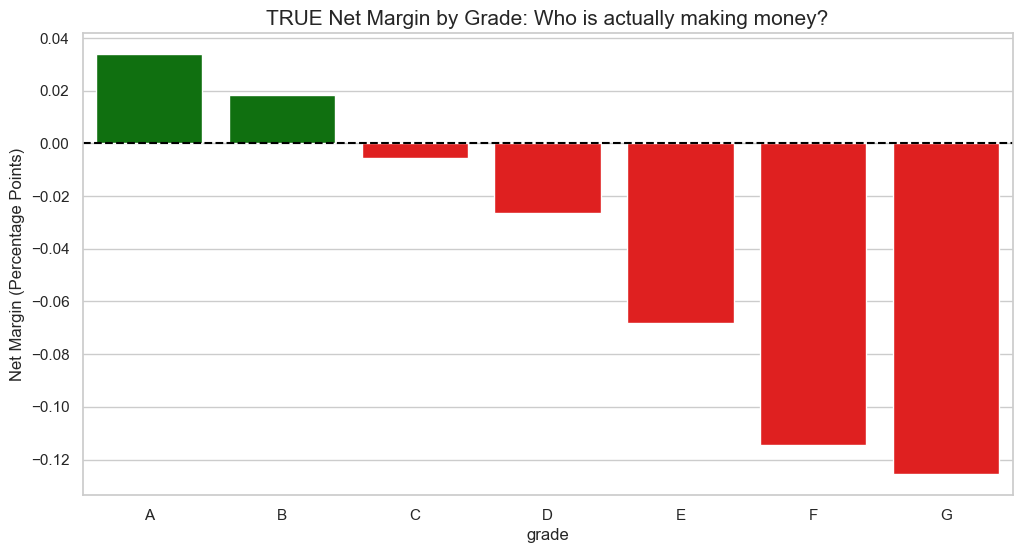

In [25]:
# Create a copy to avoid modifying original data
final_report = viz_data.copy()

# Ensure both are on the same scale (0 to 1)
# If int_rate is already like 7.08, we divide by 100
if final_report['int_rate'].max() > 1:
    final_report['int_rate_dec'] = final_report['int_rate'] / 100
else:
    final_report['int_rate_dec'] = final_report['int_rate']

# Calculate TRUE Net Margin
final_report['true_net_margin'] = final_report['int_rate_dec'] - final_report['default_rate']

print("--- TRUE Profitability Analysis (Corrected Scale) ---")
print(final_report[['int_rate_dec', 'default_rate', 'true_net_margin']])

# Visualization: The "Reality Check" Chart
plt.figure(figsize=(12, 6))
colors = ['red' if x < 0 else 'green' for x in final_report['true_net_margin']]
sns.barplot(x=final_report.index, y=final_report['true_net_margin'], palette=colors, hue=final_report.index, legend=False)
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.title('TRUE Net Margin by Grade: Who is actually making money?', fontsize=15)
plt.ylabel('Net Margin (Percentage Points)')
plt.show()

In [26]:
# Export the final calculated results for Power BI reporting
# This file only contains the summarized insights, making it super lightweight
final_report.to_csv('risk_report_summary.csv')

print("Report summary exported! You can now import 'risk_report_summary.csv' into Power BI.")

Report summary exported! You can now import 'risk_report_summary.csv' into Power BI.
